29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8126 - loss: 0.5394 - val_accuracy: 0.8508 - val_loss: 0.4356
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8594 - loss: 0.3983 - val_accuracy: 0.8504 - val_loss: 0.4227
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8708 - loss: 0.3597 - val_accuracy: 0.8596 - val_loss: 0.3973
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8813 - loss: 0.3314 - val_accuracy: 0.8782 - val_loss: 0.3508
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8868 - loss: 0.3120 - val_accuracy: 0.8756 - val_loss: 0.3466
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8923 - loss: 0.2965 - val_accuracy: 0.8754 - val_loss: 0.3505
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8973 - loss: 0.2825 - val_accuracy: 0.8743 - val_loss: 0.3500
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9000 - loss: 0.2716 - val_accuracy: 0.

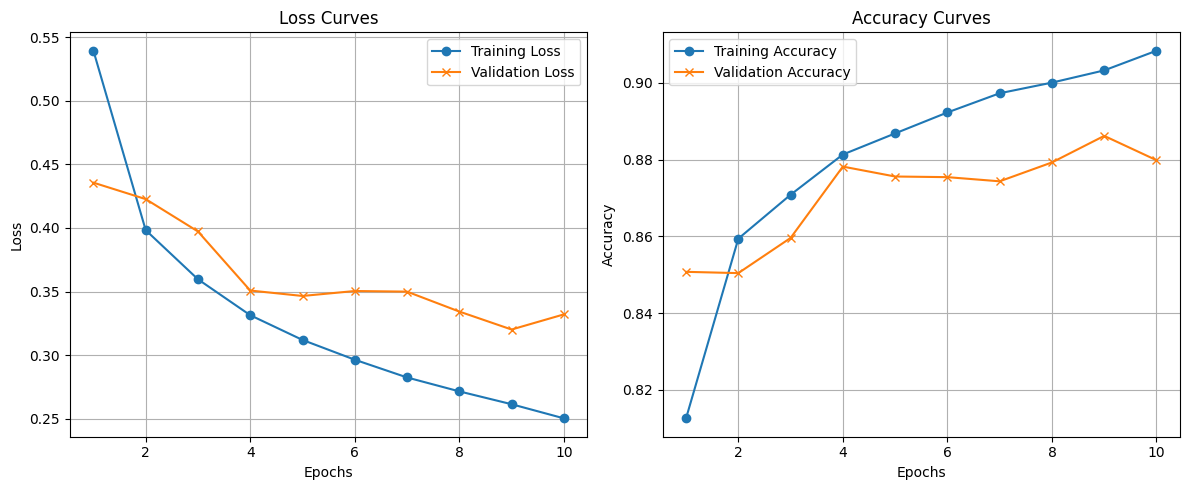

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load and preprocess the Fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = (
    fashion_mnist.load_data()
)

# Normalize pixel values to be between 0 and 1
train_images = train_images / 255.0
test_images = test_images / 255.0

# 2. Build a simple feedforward neural network
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

# 3. Compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# 4. Train the model and save the history
# Using validation_split to track generalization performance during training
history = model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_split=0.2,
    batch_size=64,
    verbose=1,
)

# 5. Plot Loss and Accuracy Curves
epochs_range = range(1, 11)

plt.figure(figsize=(12, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(
    epochs_range,
    history.history["loss"],
    label="Training Loss",
    marker="o",
)
plt.plot(
    epochs_range,
    history.history["val_loss"],
    label="Validation Loss",
    marker="x",
)
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(
    epochs_range,
    history.history["accuracy"],
    label="Training Accuracy",
    marker="o",
)
plt.plot(
    epochs_range,
    history.history["val_accuracy"],
    label="Validation Accuracy",
    marker="x",
)
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
